# 08 — Fourier: DFT directa frente a FFT

## Objetivo

Reproducir la equivalencia de las dos ramas de filtrado y reconstrucción, y medir su coste.

**Alcance:** Hito 1 actualizado.

## Datos utilizados

Par TCIA C095/1-250 de `config/default.json`. Las rutas DICOM se configuran en ese JSON; por defecto se usan data/sdct y data/ldct. Cada notebook se ejecuta de forma independiente.

## Procedimiento

Misma imagen 512×512, mismo sinograma, padding al final del eje detector hasta N=2048, Ramp discreto común y retroproyección lineal común. DFT matricial explícita O(N²) e inversa conjugada/N frente a FFT/IFFT con norm=backward. No se aplica shift en el cálculo.

**Procedencia:** results/fourier_vs_fft_tcia/comparar_fourier_tcia.py; Resultados_TCIA.pptx, diapositivas 17–20; alcance actualizado confirmado por el usuario; detalles en `../REFACTOR_MAP.md`.

## Parámetros

In [1]:
from pathlib import Path
import os
import sys
sys.dont_write_bytecode = True
start = Path.cwd().resolve()
root = next((p for p in (start, *start.parents) if (p / 'src/config.py').is_file() and (p / 'config/default.json').is_file()), None)
if root is None and (start / 'hito1-mini-tesis/src').is_dir():
    root = start / 'hito1-mini-tesis'
if root is None:
    raise RuntimeError('Abre Jupyter desde la raíz del repositorio o su carpeta notebooks.')
sys.path.insert(0, str(root))
os.environ['MPLCONFIGDIR'] = str(root / 'outputs/.matplotlib')
import numpy as np
import matplotlib.pyplot as plt
from src.config import load_config, output_path
from src.experiments import prepare_pair
from src.io import save_table, save_json
from src.visualization import show_table, finish_figure
config = load_config()
show_table([{key: config[key] for key in ('num_angles', 'sigma_gaussian', 'seed', 'filter_name', 'visual_amplification')}])

num_angles,sigma_gaussian,seed,filter_name,visual_amplification
512,1,42,ramp,5


## Resultados

In [2]:
from src.radon import generate_sinogram
from src.fourier import compare_fbp_transforms, benchmark_projection
from src.normalization import denormalize_image
from src.metrics import numerical_difference
from src.visualization import plot_fourier
pair = prepare_pair(config)
sino = generate_sinogram(pair['sdct'], pair['theta'])
result = compare_fbp_transforms(sino, pair['theta'], pair['sdct'].shape[0],
                                atol=config['fourier_atol'], rtol=config['fourier_rtol'])
dft_hu = denormalize_image(result['reconstruction_dft'], pair['scale'])
fft_hu = denormalize_image(result['reconstruction_fft'], pair['scale'])
result['metrics']['reconstrucciones_HU'] = numerical_difference(dft_hu, fft_hu)
show_table([dict(stage=stage, **values) for stage, values in result['metrics'].items()])
show_table([result['checks']])
assert all(result['checks'].values()), 'Revisar normalización, filtro, padding y geometría.'

stage,maximo,media,rmse
espectros_complejos,5.14488e-11,1.84835e-12,2.14075e-12
sinogramas_filtrados,8.5805e-13,6.30026e-15,3.45195e-14
reconstrucciones_normalizadas,1.25629e-14,2.74099e-16,3.58602e-16
fft_vs_pipeline_normalizado,1.85407e-14,4.80916e-15,6.24591e-15
reconstrucciones_HU,3.30829e-11,7.23604e-13,9.48794e-13


filtrado_equivalente,reconstruccion_equivalente,geometria_y_filtro_equivalentes_al_pipeline
True,True,True


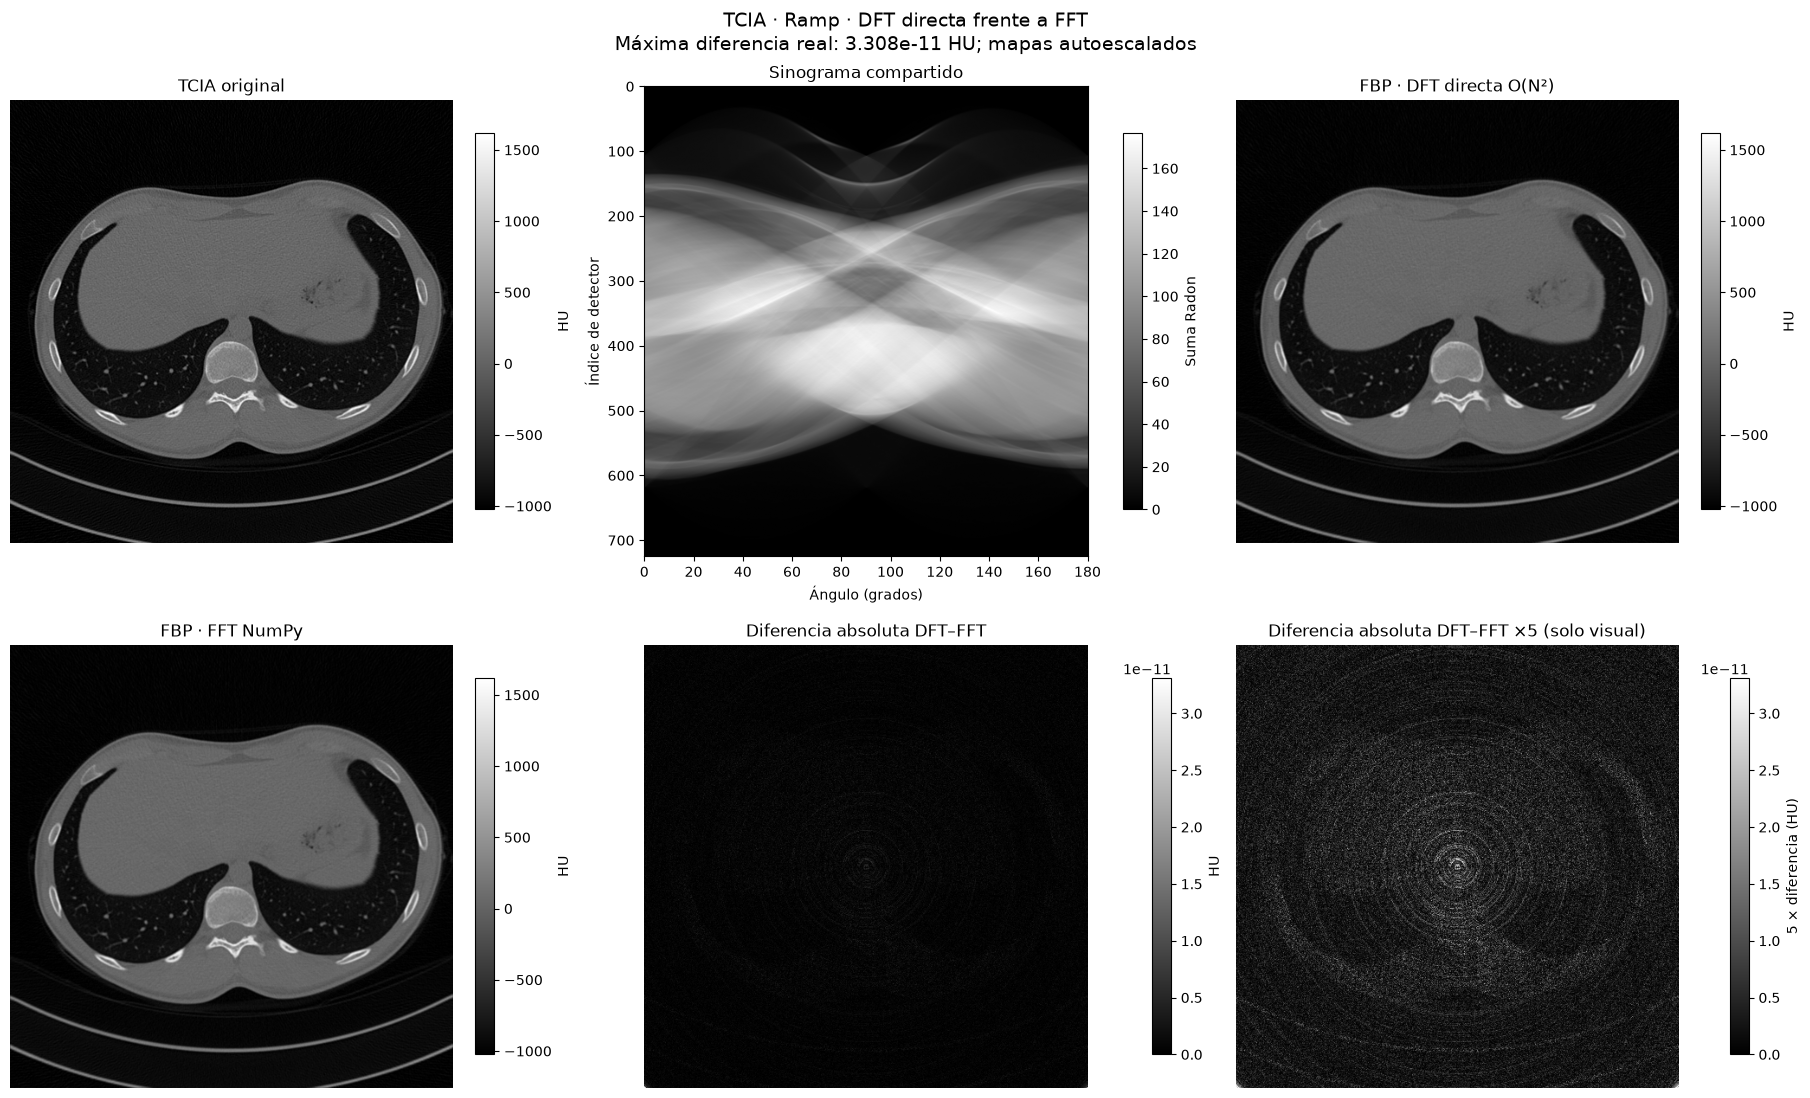

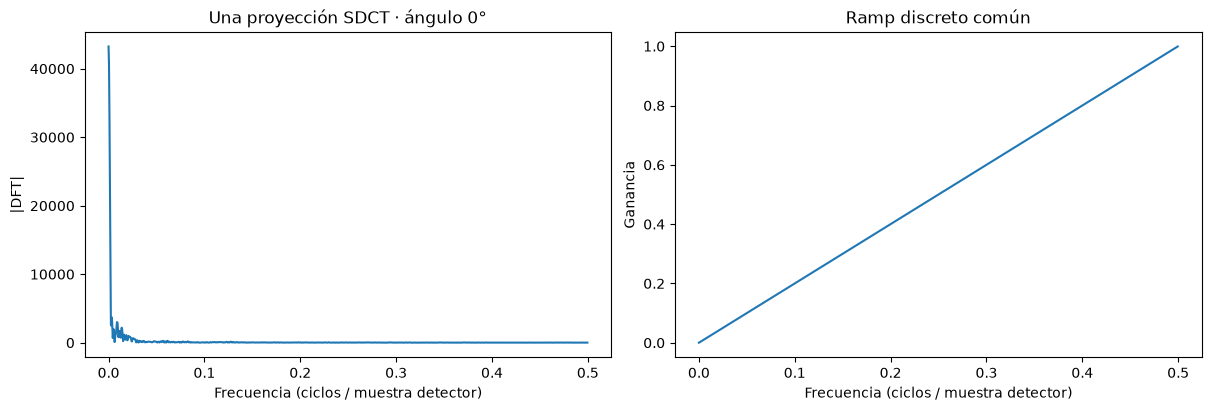

In [3]:
fig = plot_fourier(pair['sdct_hu'], sino, dft_hu, fft_hu, pair['scale'])
finish_figure(fig, output_path('figures', '08_dft_fft_reconstruction.png'))
frequencies = result['frequencies']
positive = frequencies >= 0
padded_projection = np.pad(sino[:, 0], (0, result['padding_n'] - sino.shape[0]))
spectrum = np.fft.fft(padded_projection)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
axes[0].plot(frequencies[positive], np.abs(spectrum[positive]))
axes[0].set(xlabel='Frecuencia (ciclos / muestra detector)', ylabel='|DFT|', title='Una proyección SDCT · ángulo 0°')
axes[1].plot(frequencies[positive], result['ramp'][positive, 0])
axes[1].set(xlabel='Frecuencia (ciclos / muestra detector)', ylabel='Ganancia', title='Ramp discreto común')
finish_figure(fig, output_path('figures', '08_fourier_domain.png'))

FFT es un algoritmo para calcular la misma DFT. Las diferencias de las reconstrucciones se autoescalan para mostrar redondeo; consultar las barras HU. El gráfico espectral presenta solo frecuencias no negativas y no modifica el filtrado. La siguiente medición por tamaños es un diagnóstico de rendimiento añadido al refactor, sin cambiar la reconstrucción original.

n,dft_median_s,fft_median_s,matrix_s,max_error,repeats
64,4.497e-06,5.648e-06,0.000171007,0,5
128,7.421e-06,1.0115e-05,0.000387032,6.35529e-14,5
256,8.422e-06,8.964e-06,0.00143804,3.15878e-12,5
512,1.7597e-05,1.5072e-05,0.00600545,2.91957e-11,5
1024,6.0411e-05,2.4527e-05,0.026849,1.46652e-11,5
2048,0.000444489,5.0015e-05,0.117327,1.56475e-11,5


matriz_y_filtro_comun_s,filtrado_dft_s,filtrado_fft_s,retroproyeccion_dft_s,retroproyeccion_fft_s
0.112666,0.148636,0.0420727,0.700841,0.687103


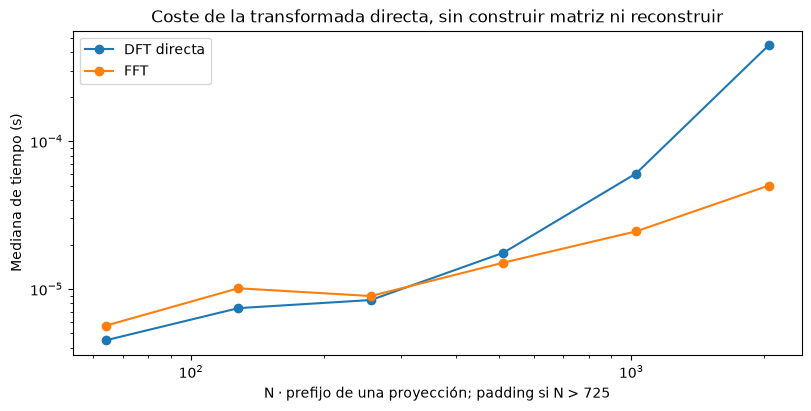

In [4]:
timing_rows = benchmark_projection(sino[:, 0], sizes=config['benchmark_sizes'], repeats=config['benchmark_repeats'])
show_table(timing_rows)
show_table([result['times']])
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
ax.loglog([r['n'] for r in timing_rows], [r['dft_median_s'] for r in timing_rows], 'o-', label='DFT directa')
ax.loglog([r['n'] for r in timing_rows], [r['fft_median_s'] for r in timing_rows], 'o-', label='FFT')
ax.set(xlabel='N · prefijo de una proyección; padding si N > 725', ylabel='Mediana de tiempo (s)',
       title='Coste de la transformada directa, sin construir matriz ni reconstruir')
ax.legend()
finish_figure(fig, output_path('figures', '08_timing_growth.png'))
save_table(timing_rows, output_path('tables', '08_timings.csv'))
save_table([dict(stage=k, **v) for k, v in result['metrics'].items()], output_path('tables', '08_fourier_metrics.csv'))
save_json({k: result[k] for k in ('metrics', 'checks', 'times', 'padding_n', 'atol', 'rtol', 'imaginary_residual')},
          output_path('tables', '08_fourier.json'))
np.savez_compressed(output_path('reconstructed_images', '08_dft_fft.npz'),
                    dft_hu=dft_hu, fft_hu=fft_hu, sinogram=sino, filtered_dft=result['filtered_dft'],
                    filtered_fft=result['filtered_fft'], frequencies=result['frequencies'], ramp=result['ramp'], theta=pair['theta'])

## Observaciones

La matriz DFT usa complex128 y ocupa 64 MiB para N=2048, además de temporales. Su construcción se informa aparte. El tiempo por tamaños corresponde a una sola proyección y cinco repeticiones; depende de BLAS, caché y equipo y no demuestra por sí solo una ley asintótica. El control independiente contra iradon Ramp debe pasar. No se disminuyó la imagen ni los ángulos en ninguna rama.